In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# --- 1. SPATIAL STRESS DATA GENERATORS ---
def create_canvas_dataset(images, canvas_size=56, random_shift=False):
    dataset = np.zeros((len(images), canvas_size, canvas_size))
    for i, img in enumerate(images):
        if random_shift:
            h_off = np.random.randint(0, canvas_size - 28 + 1)
            v_off = np.random.randint(0, canvas_size - 28 + 1)
        else:
            h_off, v_off = (canvas_size - 28) // 2, (canvas_size - 28) // 2
        dataset[i, v_off:v_off+28, h_off:h_off+28] = img
    return dataset

def apply_permutation(images_flat):
    np.random.seed(42) 
    perm_indices = np.random.permutation(images_flat.shape[1])
    return images_flat[:, perm_indices]

def apply_occlusion(images, patch_size=12):
    occluded = images.copy()
    canvas_size = images.shape[1]
    np.random.seed(24)
    for img in occluded:
        x = np.random.randint(10, canvas_size - patch_size - 10)
        y = np.random.randint(10, canvas_size - patch_size - 10)
        img[y:y+patch_size, x:x+patch_size] = 0
    return occluded

def get_cnn_features(image_data):
    rgb_data = np.repeat(image_data[..., np.newaxis], 3, -1)
    resized_data = tf.image.resize(rgb_data, [96, 96]).numpy()
    preprocessed_data = preprocess_input(resized_data)
    feature_extractor = MobileNetV2(weights='imagenet', include_top=False, input_shape=(96, 96, 3), pooling='avg')
    return feature_extractor.predict(preprocessed_data, batch_size=64, verbose=0)

# --- 2. LOAD DATA INTO MEMORY ---
print("Loading and preparing MNIST Data...")
train_samples, test_samples, canvas = 3000, 500, 56
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train, y_train = x_train[:train_samples] / 255.0, y_train[:train_samples]
x_test, y_test = x_test[:test_samples] / 255.0, y_test[:test_samples]

X_train_base = create_canvas_dataset(x_train, canvas, random_shift=False)
test_conds = {
    'Baseline': create_canvas_dataset(x_test, canvas, random_shift=False),
    'Shifted': create_canvas_dataset(x_test, canvas, random_shift=True),
    'Permuted': apply_permutation(create_canvas_dataset(x_test, canvas, random_shift=False).reshape(-1, canvas*canvas)).reshape(-1, canvas, canvas),
    'Occluded': apply_occlusion(create_canvas_dataset(x_test, canvas, random_shift=False))
}

flat_dim = canvas * canvas

# Global state trackers
trained_models = {}
master_results = {}
precomputed_test_features = {} 

print(f"Data ready! Train shape: {X_train_base.shape}")

Loading and preparing MNIST Data...
Data ready! Train shape: (3000, 56, 56)


In [2]:
print("Training Native Spatial CNN...")
cnn_model = Sequential([
    Conv2D(32, (3,3), padding='Same', activation='relu', input_shape=(canvas, canvas, 1)),
    MaxPool2D((2,2)),
    Conv2D(64, (3,3), padding='Same', activation='relu'),
    MaxPool2D((2,2)),
    Conv2D(128, (3,3), padding='Same', activation='relu'),
    GlobalAveragePooling2D(),
    Dense(10, activation="softmax")
])
cnn_model.compile(optimizer='adam', loss="sparse_categorical_crossentropy", metrics=["accuracy"])
cnn_model.fit(X_train_base.reshape(-1, canvas, canvas, 1), y_train, epochs=10, validation_split=0.1, verbose=1)

trained_models['CNN (Native)'] = cnn_model
print("CNN successfully saved to RAM.")

Training Native Spatial CNN...
Epoch 1/10


/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.1633 - loss: 2.2513 - val_accuracy: 0.3500 - val_loss: 1.9749
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.4344 - loss: 1.6270 - val_accuracy: 0.5800 - val_loss: 1.3518
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6522 - loss: 1.1417 - val_accuracy: 0.7167 - val_loss: 0.9428
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7596 - loss: 0.8217 - val_accuracy: 0.7967 - val_loss: 0.7260
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8344 - loss: 0.6191 - val_accuracy: 0.8067 - val_loss: 0.6246
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8548 - loss: 0.5293 - val_accuracy: 0.8400 - val_loss: 0.5473
Epoch 7/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8626 - loss: 0.4775 - val_accuracy: 0.8667 - val_loss: 0.4406
Epoch 8/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8848 - loss: 0.4023 - val_accuracy: 0.8833 - val_loss: 0.

In [3]:
print("Training Method A (Raw Pixels)...")
X_train_flat = X_train_base.reshape(-1, flat_dim)

# XGBoost
xgb_raw = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, tree_method='hist', n_jobs=-1)
print("  -> Fitting XGBoost (Raw)...")
xgb_raw.fit(X_train_flat, y_train)
trained_models['XGBoost (Raw)'] = xgb_raw

# LightGBM
lgb_raw = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, verbosity=-1, n_jobs=-1)
print("  -> Fitting LightGBM (Raw)...")
lgb_raw.fit(X_train_flat, y_train)
trained_models['LightGBM (Raw)'] = lgb_raw

# CatBoost
cb_raw = CatBoostClassifier(n_estimators=100, learning_rate=0.1, verbose=0, thread_count=-1)
print("  -> Fitting CatBoost (Raw)...")
cb_raw.fit(X_train_flat, y_train)
trained_models['CatBoost (Raw)'] = cb_raw

print("Method A models successfully saved to RAM.")

Training Method A (Raw Pixels)...
  -> Fitting XGBoost (Raw)...
  -> Fitting LightGBM (Raw)...
  -> Fitting CatBoost (Raw)...
Method A models successfully saved to RAM.


In [4]:
print("Training Method B (Hybrid CNN+GBDTs)...")

print("  -> Extracting CNN Features for Training Data...")
X_train_features = get_cnn_features(X_train_base)

if not precomputed_test_features:
    for cond_name, X_test in test_conds.items():
        print(f"  -> Extracting CNN Features for {cond_name} Test Data...")
        precomputed_test_features[cond_name] = get_cnn_features(X_test)

# XGBoost Hybrid
xgb_hybrid = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, tree_method='hist', n_jobs=-1)
print("  -> Fitting XGBoost (CNN Feat)...")
xgb_hybrid.fit(X_train_features, y_train)
trained_models['XGBoost (CNN Feat)'] = xgb_hybrid

# LightGBM Hybrid
lgb_hybrid = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, verbosity=-1, n_jobs=-1)
print("  -> Fitting LightGBM (CNN Feat)...")
lgb_hybrid.fit(X_train_features, y_train)
trained_models['LightGBM (CNN Feat)'] = lgb_hybrid

# CatBoost Hybrid
cb_hybrid = CatBoostClassifier(n_estimators=100, learning_rate=0.1, verbose=0, thread_count=-1)
print("  -> Fitting CatBoost (CNN Feat)...")
cb_hybrid.fit(X_train_features, y_train)
trained_models['CatBoost (CNN Feat)'] = cb_hybrid

print("Method B models successfully saved to RAM.")

Training Method B (Hybrid CNN+GBDTs)...
  -> Extracting CNN Features for Training Data...
  -> Extracting CNN Features for Baseline Test Data...
  -> Extracting CNN Features for Shifted Test Data...
  -> Extracting CNN Features for Permuted Test Data...
  -> Extracting CNN Features for Occluded Test Data...
  -> Fitting XGBoost (CNN Feat)...
  -> Fitting LightGBM (CNN Feat)...
  -> Fitting CatBoost (CNN Feat)...
Method B models successfully saved to RAM.


In [5]:
print("Evaluating all models currently in RAM...")

for name, model in trained_models.items():
    print(f"  -> Evaluating {name}...")
    master_results[name] = {}
    
    for cond_name, X_test in test_conds.items():
        if "Native" in name:
            _, acc = model.evaluate(X_test.reshape(-1, canvas, canvas, 1), y_test, verbose=0)
        elif "Raw" in name:
            acc = accuracy_score(y_test, model.predict(X_test.reshape(-1, flat_dim)))
        elif "Feat" in name:
            acc = accuracy_score(y_test, model.predict(precomputed_test_features[cond_name]))
            
        master_results[name][cond_name] = acc

print("\nEvaluation Complete! Results updated in RAM.")

Evaluating all models currently in RAM...
  -> Evaluating CNN (Native)...
  -> Evaluating XGBoost (Raw)...
  -> Evaluating LightGBM (Raw)...
  -> Evaluating CatBoost (Raw)...
  -> Evaluating XGBoost (CNN Feat)...
  -> Evaluating LightGBM (CNN Feat)...
  -> Evaluating CatBoost (CNN Feat)...

Evaluation Complete! Results updated in RAM.


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/

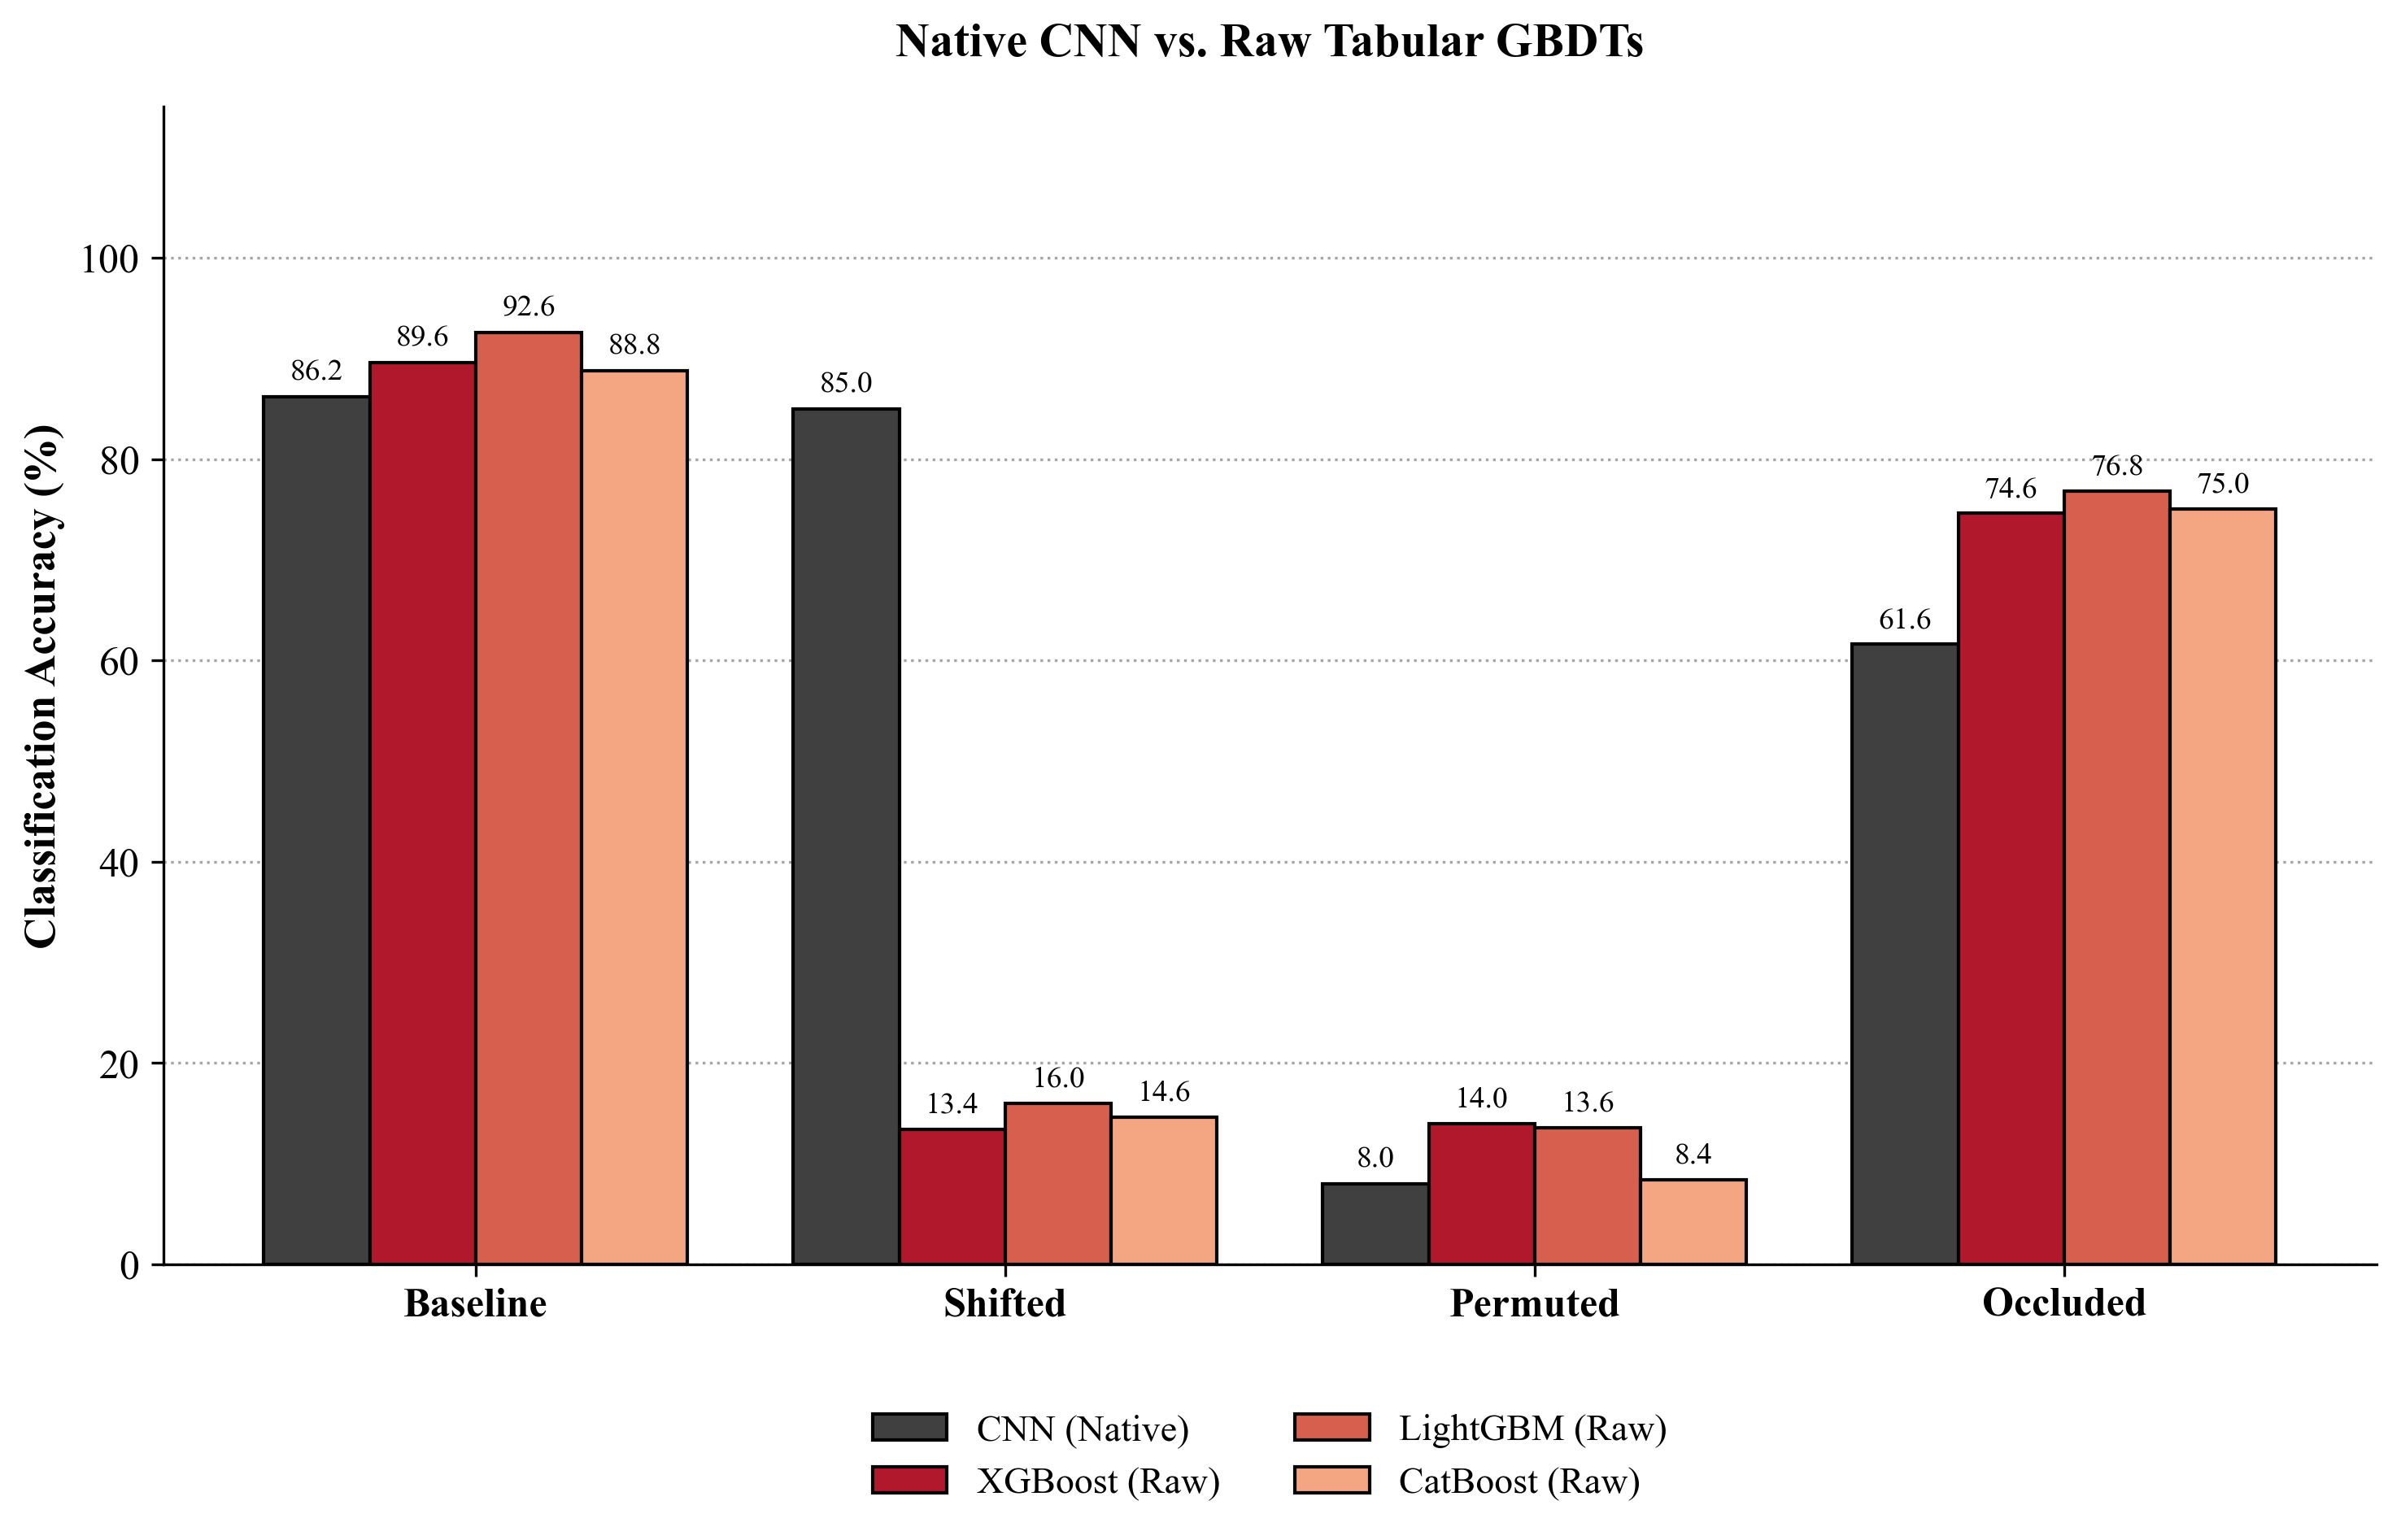

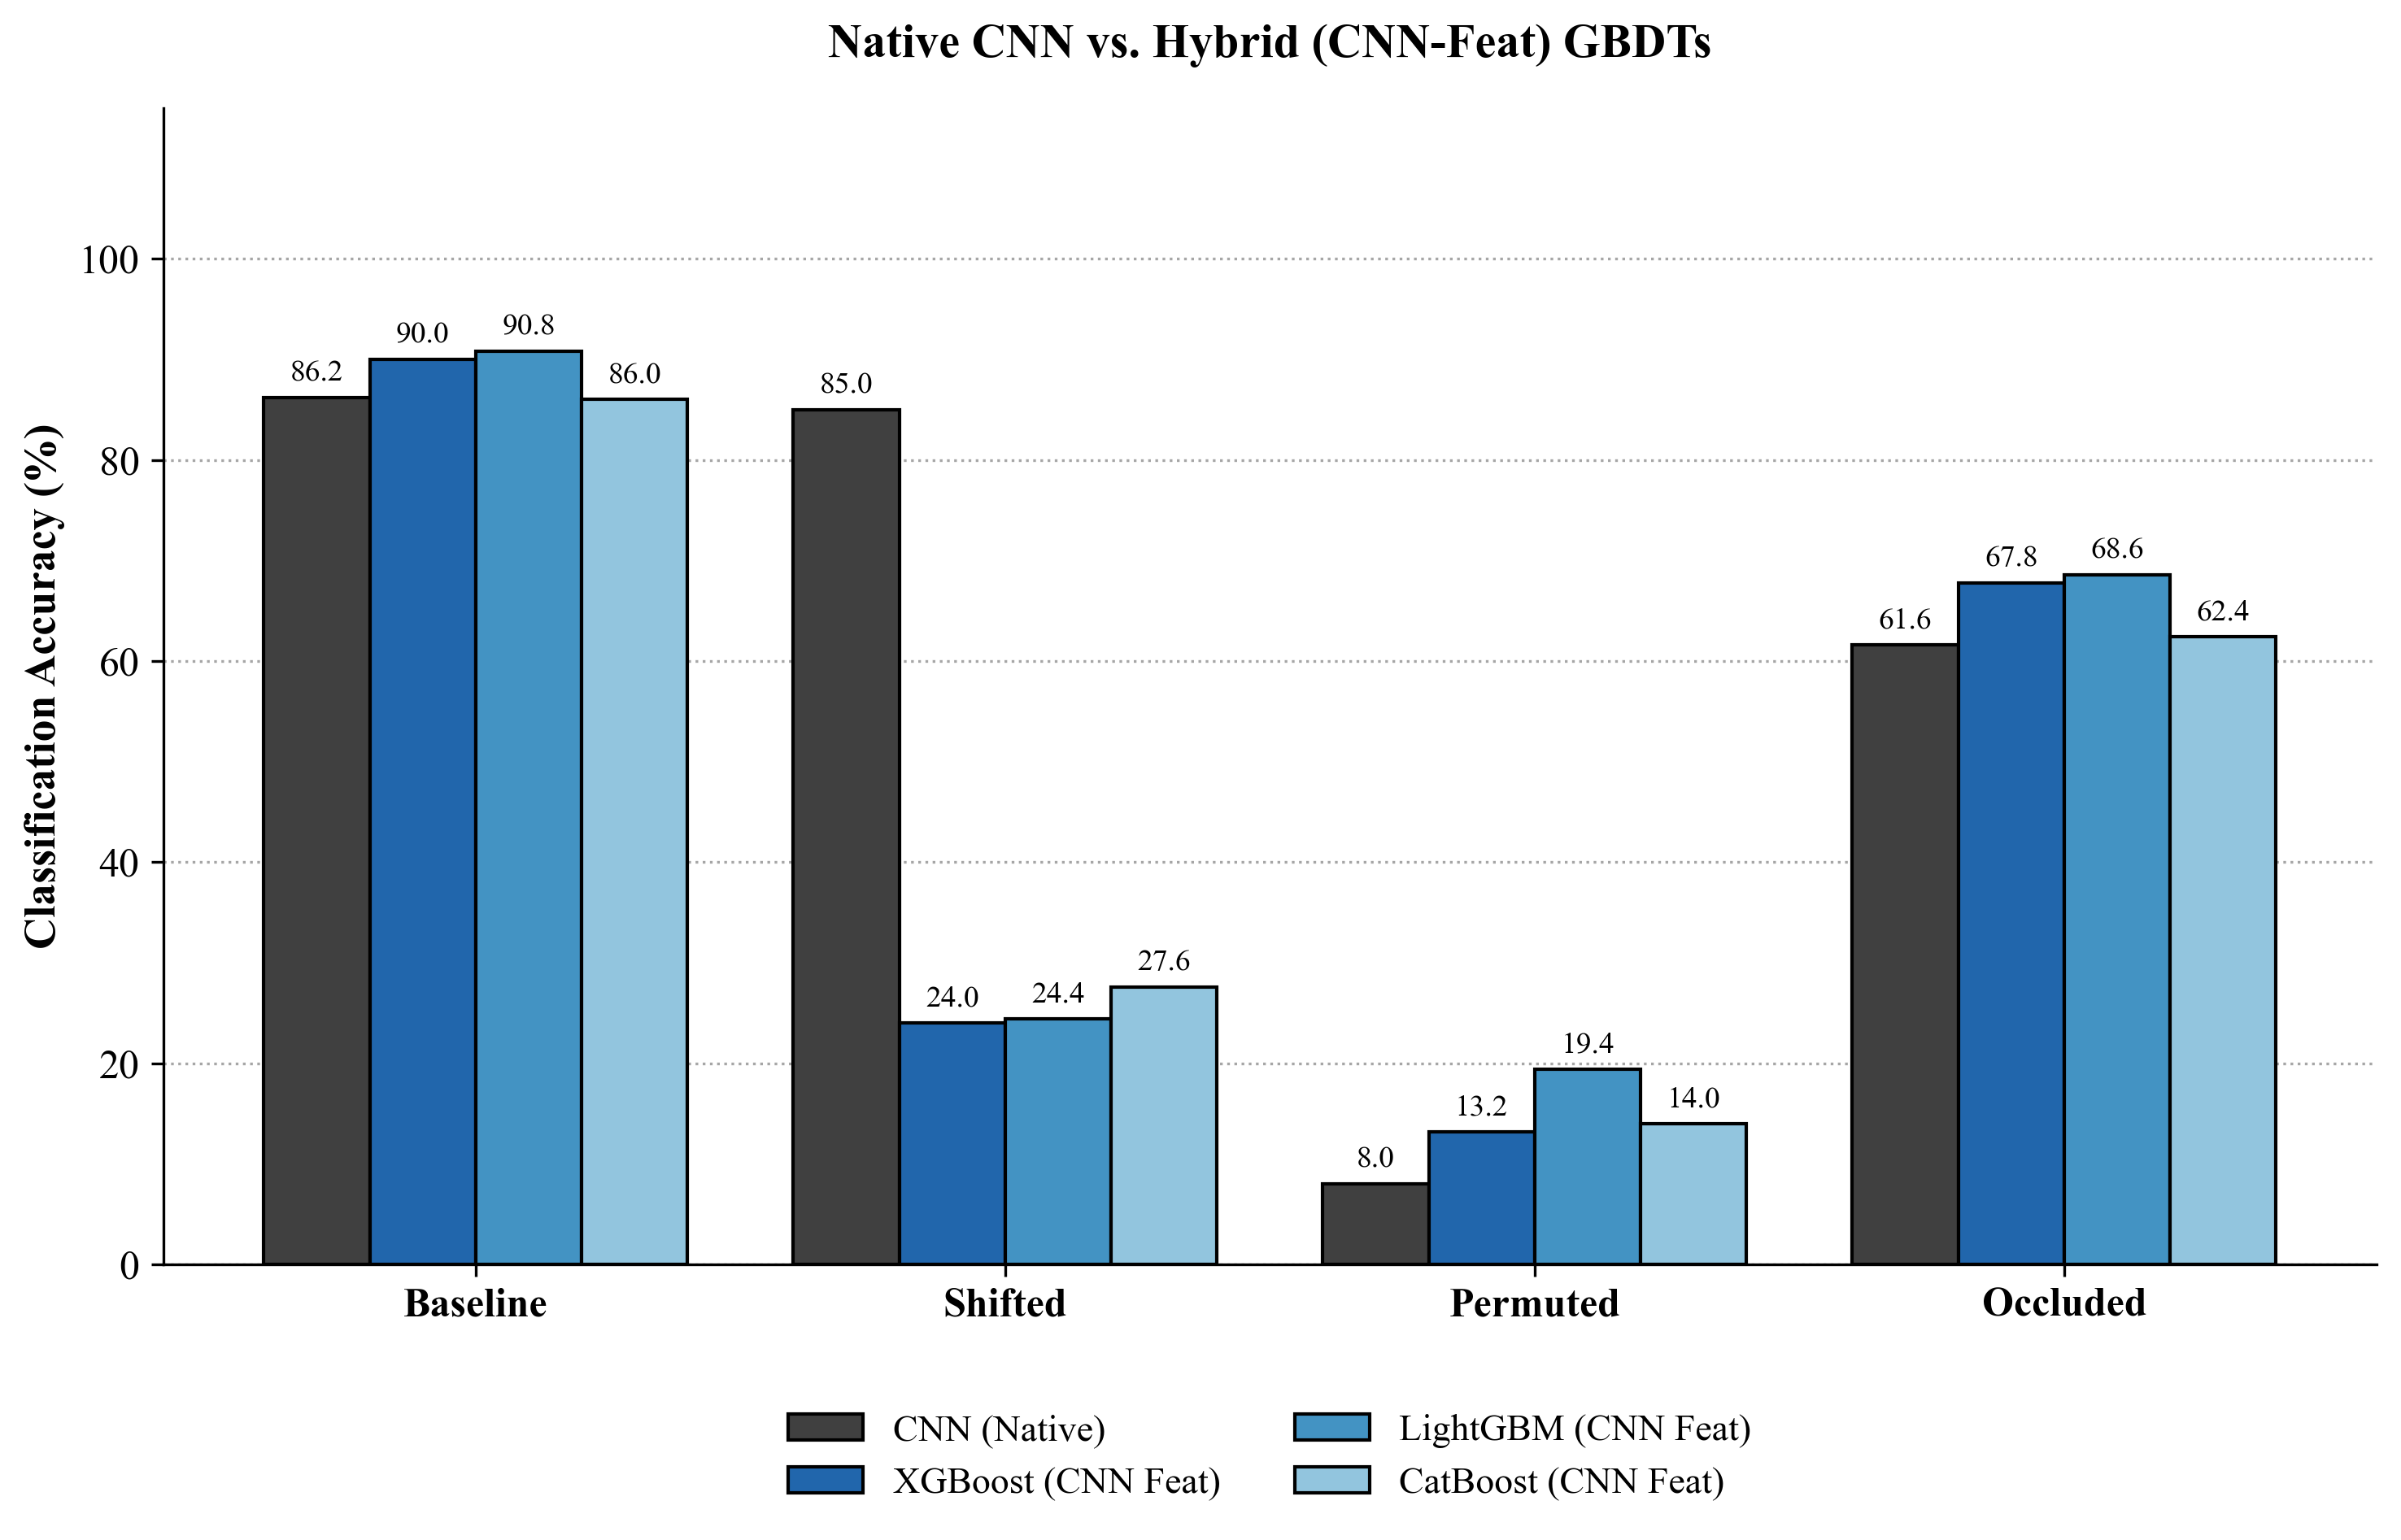

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def draw_publication_separated_plots(results):
    if not results:
        print("No results to plot! Run the evaluation cell first.")
        return
        
    # 1. Base typographic settings for academic publication
    plt.rcParams.update({
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'DejaVu Serif'], 
        'font.size': 12, 'axes.labelsize': 13, 'axes.titlesize': 14,
        'figure.dpi': 300, 'savefig.dpi': 300, 'savefig.bbox': 'tight'
    })

    models_in_results = list(results.keys())
    conditions = list(results[models_in_results[0]].keys())
    
    x = np.arange(len(conditions))
    width = 0.2 
    
    # 2. Color Mapping
    color_map = {
        'CNN (Native)': '#404040', # Neutral Dark Gray
        'XGBoost (Raw)': '#B2182B', 'LightGBM (Raw)': '#D6604D', 'CatBoost (Raw)': '#F4A582', # Warm Reds
        'XGBoost (CNN Feat)': '#2166AC', 'LightGBM (CNN Feat)': '#4393C3', 'CatBoost (CNN Feat)': '#92C5DE' # Cool Blues
    }

    def add_value_labels(ax):
        """Adds text labels above the bars for precise readability."""
        for rect in ax.patches:
            height = rect.get_height()
            if height > 0:
                ax.annotate(f'{height:.1f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3), 
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=9, color='black')

    # ==========================================
    # FIGURE 1: CNN vs Raw Tabular Models
    # ==========================================
    # Set figsize to standard full-width for a single plot
    fig1, ax1 = plt.subplots(figsize=(10, 6.5))
    
    group1 = ['CNN (Native)', 'XGBoost (Raw)', 'LightGBM (Raw)', 'CatBoost (Raw)']
    models1 = [m for m in group1 if m in results]
    
    for i, model in enumerate(models1):
        scores = [results[model][cond] * 100 for cond in conditions]
        offset = (i - len(models1)/2 + 0.5) * width
        
        ax1.bar(x + offset, scores, width, label=model, color=color_map[model], 
                edgecolor='black', linewidth=1.0, zorder=3)
        
    ax1.set_ylabel('Classification Accuracy (%)', weight='bold')
    ax1.set_title('Native CNN vs. Raw Tabular GBDTs', weight='bold', pad=15)
    ax1.set_xticks(x)
    ax1.set_xticklabels(conditions, weight='bold')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.set_yticks(np.arange(0, 101, 20))
    ax1.grid(axis='y', linestyle=':', color='gray', alpha=0.7, zorder=0)
    ax1.set_ylim(0, 115) # Extended limit to accommodate data labels
    
    add_value_labels(ax1)
    ax1.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=11)

    plt.tight_layout()
    plt.savefig('Phase_5_Plot_A_Raw.pdf')
    plt.show() # Renders Figure 1

    # ==========================================
    # FIGURE 2: CNN vs Hybrid Models
    # ==========================================
    # Create a completely fresh figure for the second plot
    fig2, ax2 = plt.subplots(figsize=(10, 6.5))
    
    group2 = ['CNN (Native)', 'XGBoost (CNN Feat)', 'LightGBM (CNN Feat)', 'CatBoost (CNN Feat)']
    models2 = [m for m in group2 if m in results]
    
    for i, model in enumerate(models2):
        scores = [results[model][cond] * 100 for cond in conditions]
        offset = (i - len(models2)/2 + 0.5) * width
        
        ax2.bar(x + offset, scores, width, label=model, color=color_map[model], 
                edgecolor='black', linewidth=1.0, zorder=3)
        
    ax2.set_ylabel('Classification Accuracy (%)', weight='bold')
    ax2.set_title('Native CNN vs. Hybrid (CNN-Feat) GBDTs', weight='bold', pad=15)
    ax2.set_xticks(x)
    ax2.set_xticklabels(conditions, weight='bold')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.set_yticks(np.arange(0, 101, 20)) # Ensure Y-axis is visible on this isolated plot
    ax2.grid(axis='y', linestyle=':', color='gray', alpha=0.7, zorder=0)
    ax2.set_ylim(0, 115)
    
    add_value_labels(ax2)
    ax2.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=11)

    plt.tight_layout()
    plt.savefig('Phase_5_Plot_B_Hybrid.pdf')
    plt.show() # Renders Figure 2

# Execute plot
draw_publication_separated_plots(master_results)

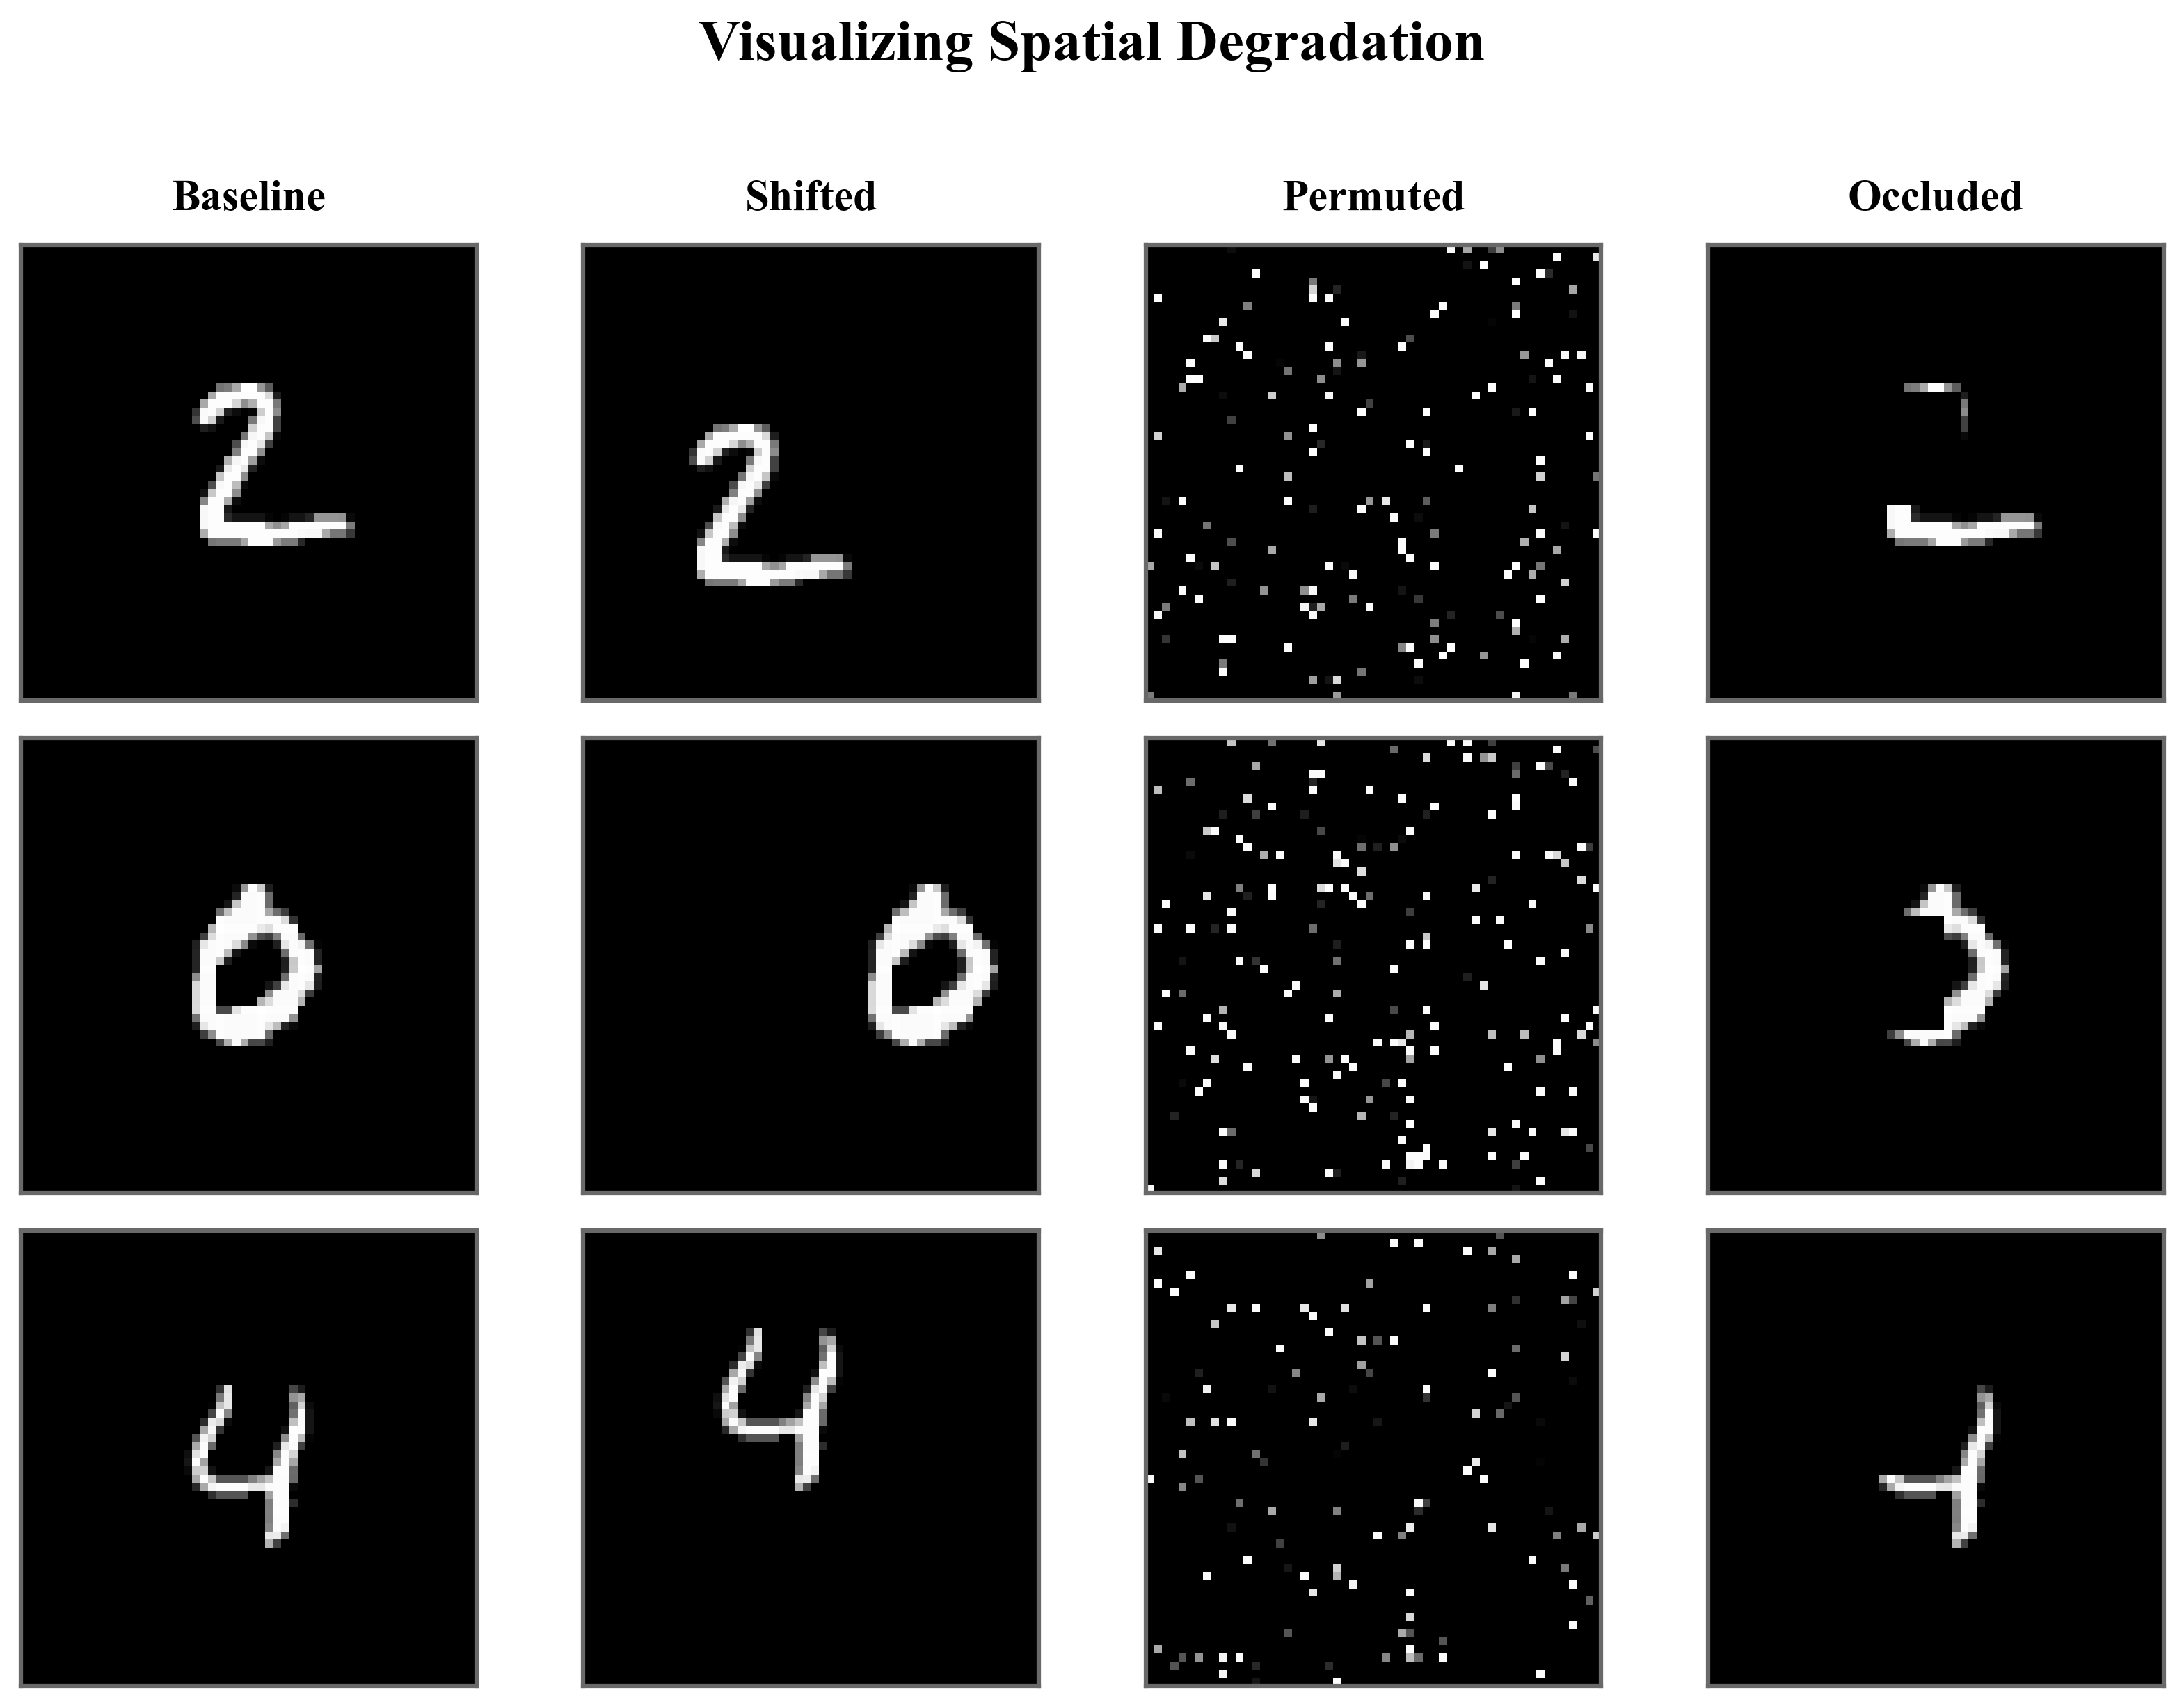

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# ==========================================
# 1. SPATIAL STRESS FUNCTIONS
# ==========================================
def create_canvas_dataset(images, canvas_size=56, random_shift=False):
    dataset = np.zeros((len(images), canvas_size, canvas_size))
    for i, img in enumerate(images):
        if random_shift:
            h_off = np.random.randint(0, canvas_size - 28 + 1)
            v_off = np.random.randint(0, canvas_size - 28 + 1)
        else:
            h_off, v_off = (canvas_size - 28) // 2, (canvas_size - 28) // 2
        dataset[i, v_off:v_off+28, h_off:h_off+28] = img
    return dataset

def apply_permutation(images_flat):
    np.random.seed(42)
    perm_indices = np.random.permutation(images_flat.shape[1])
    return images_flat[:, perm_indices]

# ==========================================
# 2. DATA PREPARATION
# ==========================================
# Load specific visually distinct samples from MNIST (e.g., 2, 0, 4)
(_, _), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# We pick specific indices from x_test that represent a 2, a 0, and a 4 for variety
sample_images = np.array([x_test[1], x_test[3], x_test[4]]) / 255.0 
canvas_size = 56

# A. Baseline
baseline = create_canvas_dataset(sample_images, canvas_size, random_shift=False)

# B. Shifted
np.random.seed(42) # Ensure reproducible random shifts
shifted = create_canvas_dataset(sample_images, canvas_size, random_shift=True)

# C. Permuted
permuted = apply_permutation(baseline.reshape(-1, canvas_size*canvas_size)).reshape(-1, canvas_size, canvas_size)

# D. Occluded
occluded = baseline.copy()
np.random.seed(24) # Ensure reproducible occlusion patches
patch_size = 14

for img in occluded:
    # Restrict random choice to the center so the black patch actually hits the digit
    x = np.random.randint(15, canvas_size - patch_size - 15)
    y = np.random.randint(15, canvas_size - patch_size - 15)
    img[y:y+patch_size, x:x+patch_size] = 0

# ==========================================
# 3. PUBLICATION-STYLE PLOTTING
# ==========================================
conditions = ['Baseline', 'Shifted', 'Permuted', 'Occluded']
data = [baseline, shifted, permuted, occluded]

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'], 
})

fig, axes = plt.subplots(3, 4, figsize=(11, 8))
for row in range(3):
    for col in range(4):
        ax = axes[row, col]
        ax.imshow(data[col][row], cmap='gray')
        
        # Add a subtle border to define the 56x56 canvas clearly
        for spine in ax.spines.values():
            spine.set_edgecolor('dimgray')
            spine.set_linewidth(1.5)
            
        ax.set_xticks([])
        ax.set_yticks([])
        
        # Column Titles on the top row
        if row == 0:
            ax.set_title(conditions[col], fontsize=15, fontweight='bold', pad=12)

plt.suptitle("Visualizing Spatial Degradation", fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()

# Save as vector PDF for pristine quality in your LaTeX or Word doc
plt.savefig("spatial_stress_visualization.pdf", bbox_inches='tight', dpi=300)
plt.show()